# AI304 Unsupervised Learning Lab
## Notebook 1: Data Understanding and Preprocessing

In [13]:
# ─────────────────────────────────────────────
# Install required libraries (run once)
# numpy 1.26.4 is pinned for compatibility with scikit-learn-extra
# ─────────────────────────────────────────────
!pip install numpy==1.26.4 --quiet
!pip install scikit-learn-extra --quiet
!pip install seaborn --quiet

  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [19 lines of output]
      + C:\Users\mohan sharma\AppData\Local\Programs\Python\Python313\python.exe C:\Users\mohan sharma\AppData\Local\Temp\pip-install-7_ge7br5\numpy_2e04dc52974c4a778b43a8bc55fafd8e\vendored-meson\meson\meson.py setup C:\Users\mohan sharma\AppData\Local\Temp\pip-install-7_ge7br5\numpy_2e04dc52974c4a778b43a8bc55fafd8e C:\Users\mohan sharma\AppData\Local\Temp\pip-install-7_ge7br5\numpy_2e04dc52974c4a778b43a8bc55fafd8e\.mesonpy-65r9bl5k -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\mohan sharma\AppData\Local\Temp\pip-install-7_ge7br5\numpy_2e04dc52974c4a778b43a8bc55fafd8e\.mesonpy-65r9bl5k\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.99
      Source dir: C:\Users\mohan sharma\AppData\Local\Temp\pip-install-7_ge7br5\numpy_2e04dc52974c4a778b43a8bc55fafd8e
      Build dir: C:\User

In [14]:
# ─────────────────────────────────────────────
# Import core libraries
# pandas  → tabular data manipulation
# numpy   → numerical operations
# matplotlib/seaborn → visualization
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [15]:
# ─────────────────────────────────────────────
# Load the raw dataset
# sep=';'         → the file uses semicolons as delimiters
# low_memory=False → prevents dtype guessing errors on large files
# ─────────────────────────────────────────────
df_raw = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    low_memory=False
)

print(f"Dataset shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head()

Dataset shape: (2075259, 9)
Columns: ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [16]:
# ─────────────────────────────────────────────
# Step 1: Replace '?' with NaN
# The dataset encodes missing values as '?' strings.
# We convert these to numpy NaN for standard handling.
# ─────────────────────────────────────────────
df = df_raw.replace('?', np.nan)

# Count missing values per column before dropping
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [17]:
# ─────────────────────────────────────────────
# Step 2: Drop rows with any missing values
# Missing data represents ~1.25% of rows — safe to discard.
# ─────────────────────────────────────────────
rows_before = len(df)
df = df.dropna()
rows_after = len(df)

print(f"Rows removed: {rows_before - rows_after} ({(rows_before-rows_after)/rows_before*100:.2f}%)")
print(f"Remaining rows: {rows_after}")

Rows removed: 25979 (1.25%)
Remaining rows: 2049280


In [18]:
# ─────────────────────────────────────────────
# Step 3: Convert numeric columns from object to float
# All 7 measurement columns were read as strings due to
# the mixed '?' values. We cast them to float now.
# ─────────────────────────────────────────────
numeric_cols = [
    'Global_active_power',    # Total active power drawn (kilowatts)
    'Global_reactive_power',  # Reactive power (kilowatts)
    'Voltage',                # Household voltage (volts)
    'Global_intensity',       # Current intensity (amps)
    'Sub_metering_1',         # Kitchen appliances energy (watt-hours)
    'Sub_metering_2',         # Laundry appliances energy (watt-hours)
    'Sub_metering_3'          # HVAC/water heater energy (watt-hours)
]

for col in numeric_cols:
    df[col] = df[col].astype(float)

print("Data types after conversion:")
print(df[numeric_cols].dtypes)

Data types after conversion:
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


In [19]:
# ─────────────────────────────────────────────
# Step 4: Combine Date and Time into a single datetime index
# This allows time-based resampling (e.g., daily, hourly)
# dd/mm/yyyy format is used in the dataset.
# ─────────────────────────────────────────────
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

# Set datetime as the index for time-series operations
df = df.set_index('datetime')

# Drop original Date and Time columns (now redundant)
df = df.drop(columns=['Date', 'Time'])

print(f"Date range: {df.index.min()} to {df.index.max()}")
df.head()

Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [20]:
# ─────────────────────────────────────────────
# Step 5: Summary statistics of the cleaned dataset
# Provides an overview of ranges, mean values, and variability
# ─────────────────────────────────────────────
df[numeric_cols].describe().round(3)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2049280.000,2049280.000,2049280.00,2049280.000,2049280.000,2049280.000,2049280.000
mean,1.092,0.124,240.84,4.628,1.122,1.299,6.458
std,1.057,0.113,3.24,4.444,6.153,5.822,8.437
min,0.076,0.000,223.20,0.200,0.000,0.000,0.000
25%,0.308,0.048,238.99,1.400,0.000,0.000,0.000
50%,0.602,0.100,241.01,2.600,0.000,0.000,1.000
75%,1.528,0.194,242.89,6.400,0.000,1.000,17.000
max,11.122,1.390,254.15,48.400,88.000,80.000,31.000


C:\Users\mohan sharma\AppData\Local\Temp\ipykernel_744\1940937822.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['Global_active_power'].resample('H').mean().plot(ax=ax, color='steelblue', linewidth=0.8)


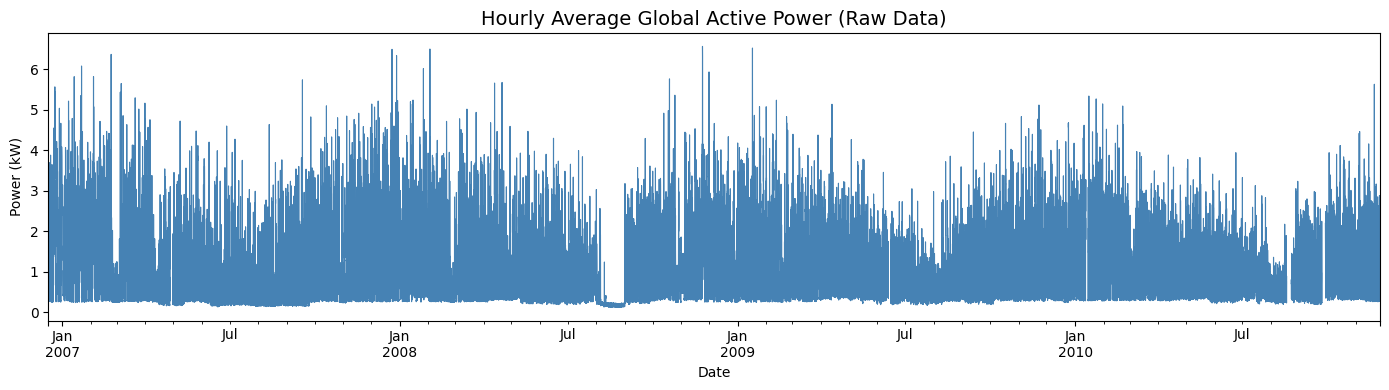

In [21]:
# ─────────────────────────────────────────────
# Step 6: Visualize raw Global Active Power over time
# Helps confirm the data is loaded correctly and shows
# any visible seasonality or long-term trends.
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

# Resample to hourly averages for a manageable plot
df['Global_active_power'].resample('H').mean().plot(ax=ax, color='steelblue', linewidth=0.8)

ax.set_title("Hourly Average Global Active Power (Raw Data)", fontsize=14)
ax.set_ylabel("Power (kW)")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

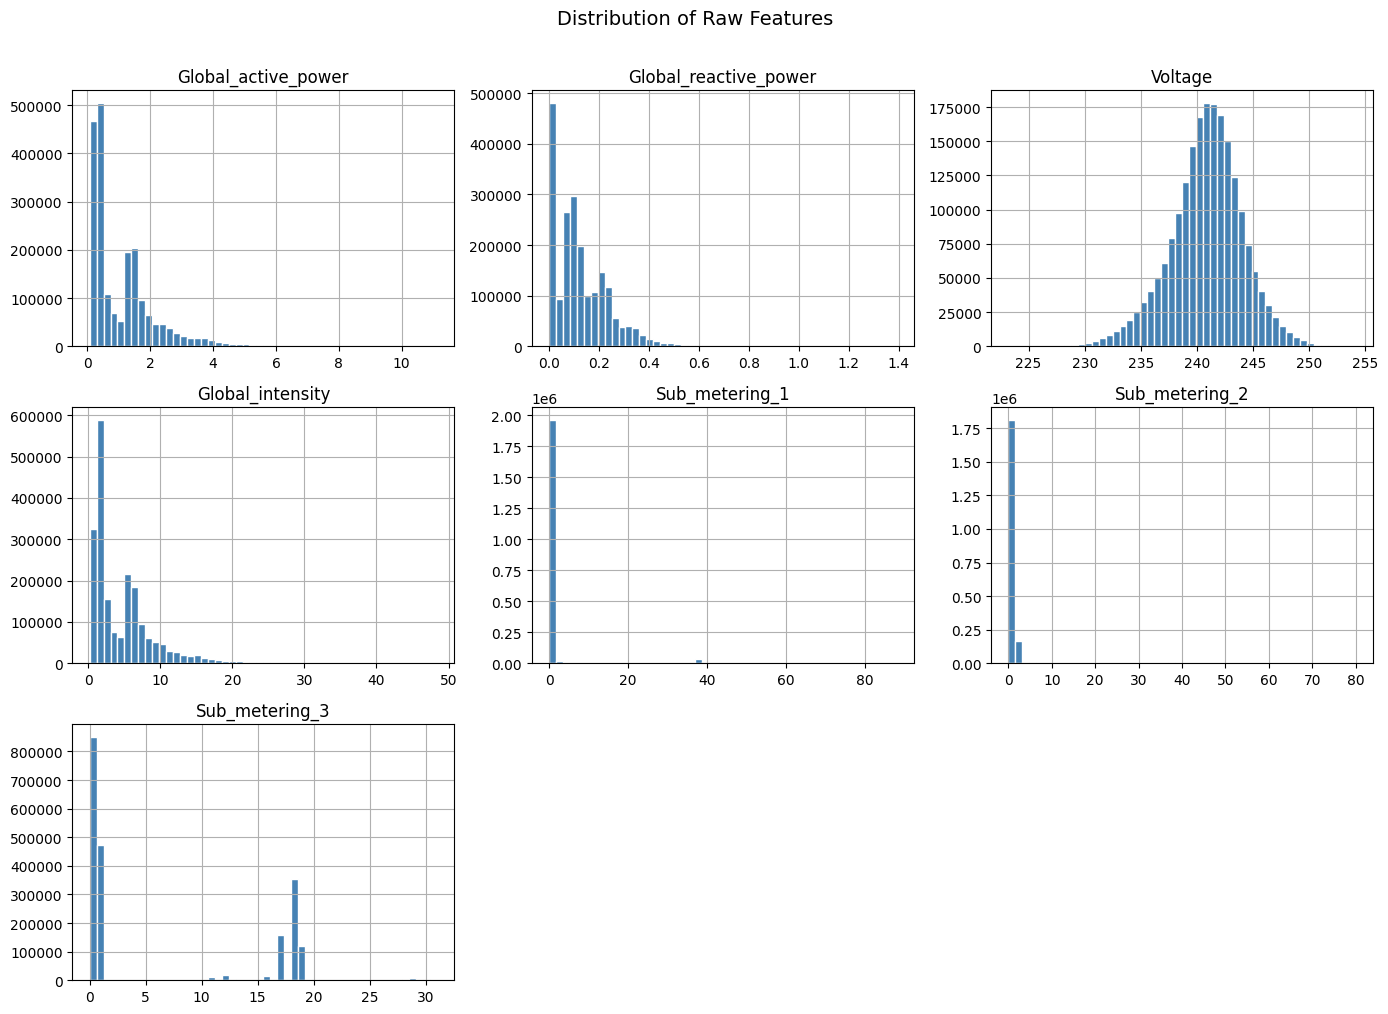

In [22]:
# ─────────────────────────────────────────────
# Step 7: Distribution of each numeric feature
# Histograms reveal skewness, outliers, and overall shape
# ─────────────────────────────────────────────
df[numeric_cols].hist(bins=50, figsize=(14, 10), color='steelblue', edgecolor='white')
plt.suptitle("Distribution of Raw Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

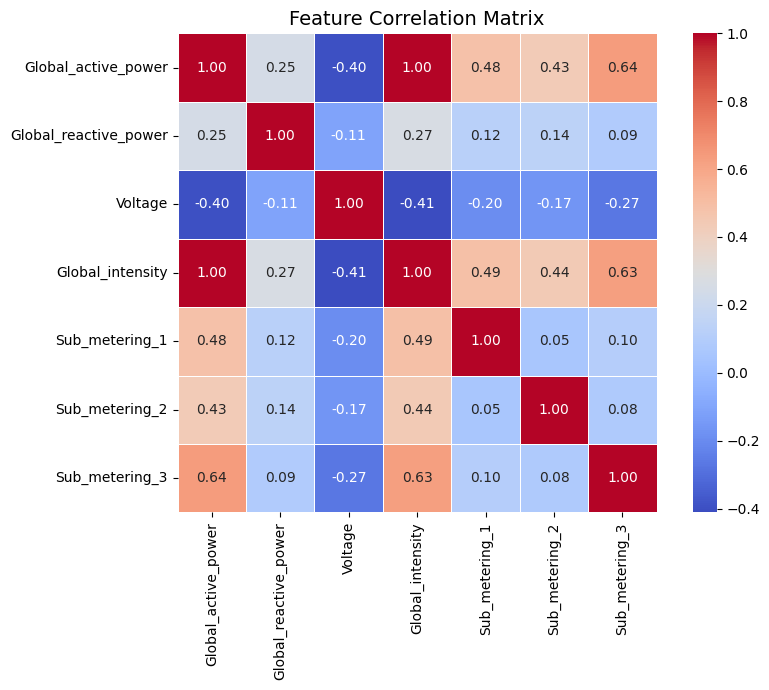

In [23]:
# ─────────────────────────────────────────────
# Step 8: Correlation heatmap
# Shows linear relationships between features.
# Highly correlated features may carry redundant information.
# ─────────────────────────────────────────────
plt.figure(figsize=(9, 7))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
# ─────────────────────────────────────────────
# Step 9: Save cleaned dataset to CSV
# This file is used as the starting point in Notebook 2
# (Feature Engineering).
# ─────────────────────────────────────────────
df.to_csv("cleaned_power_data.csv")
print("Cleaned dataset saved to 'cleaned_power_data.csv'")
print(f"Final shape: {df.shape}")

Cleaned dataset saved to 'cleaned_power_data.csv'
Final shape: (2049280, 7)
